In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud
import folium
from folium.plugins import HeatMap

from IPython.display import display

import requests

## Data Prerprocessing

In [2]:
with open('./Data/GPT Results/AI_Trial_Results_v4.json') as json_file:
   results = json.load(json_file) ## extract AI role for old trial


with open('./Data/GPT Results/AI_Trial_Results_Feb_5_v6.json') as json_file:
   results_v6 = json.load(json_file) ## extract data modality and application for old trial

with open('./Data/GPT Results/AI_Trial_Results_10_13.json') as json_file:
   results_10_13 = json.load(json_file) ## extract for new trial

with open('./Data/GPT Results/AI_Trial_Results_1_14_2026.json') as json_file:
   results_1_14 = json.load(json_file) ## extract for new trial

In [3]:
### For OLD Trials

no_result = []
gpt_results = {}
for row in results:
    if row["gpt-result"] is not None:
        study_id = row["Study ID"]
        ai_role = [row["gpt-result"].split(".")[0].split(" is ")[1].strip()]
        gpt_results[study_id] = ai_role
    else:
        no_result.append(row["Study ID"])


for row in results_v6:
    if row["gpt-result"] is not None:
        study_id = row["Study ID"]

        pattern = r" data modality is\s*(.*?)\."
        match = re.search(pattern, row["gpt-result"])
        if match:
            modality = match.group(1).strip()
        else:
            pattern = r" data modalities are\s*(.*?)\."
            match = re.search(pattern, row["gpt-result"])
            if match:
                modality = match.group(1).strip()
            else:
                modality = "Not Specified"

        pattern = r" AI application is\s*(.*?)\."
        match = re.search(pattern, row["gpt-result"])
        if match:
            application = match.group(1).strip()
        else:
            pattern = r" AI application are\s*(.*?)\."
            match = re.search(pattern, row["gpt-result"])
            if match:
                application = match.group(1).strip()
            else:
                application = "Not Specified"

        gpt_results.setdefault(study_id, []).extend([modality, application])
    else:
        no_result.append(row["Study ID"])


# 1. Setup the data
data = gpt_results.items()
df_temp = pd.DataFrame(data, columns=['Study ID', 'Categories'])

# 2. Expand the list column into separate columns
tags_df = pd.DataFrame(df_temp['Categories'].tolist(), index=df_temp.index)

# 3. Join back with the original ID
df_old = pd.concat([df_temp['Study ID'], tags_df], axis=1)

df_old.columns = ["Study ID", "AI Role", "Data Modality", "AI Application"]

In [4]:
### for NEW trials

no_result = []
gpt_results = {}
for row in results_10_13:
    if row["gpt-result"] is not None:
        study_id = row["Study ID"]
        ai_role = row["gpt-result"].split(".")[0].split(" is ")[1].strip().replace("*", "")

        pattern = r" data modality is\s*(.*?)\."
        match = re.search(pattern, row["gpt-result"])
        if match:
            modality = match.group(1).strip().replace("*", "")
        else:
            pattern = r" data modalities are\s*(.*?)\."
            match = re.search(pattern, row["gpt-result"])
            if match:
                modality = match.group(1).strip().replace("*", "")
            else:
                modality = "Not Specified"

        pattern = r" AI application is\s*(.*?)\."
        match = re.search(pattern, row["gpt-result"])
        if match:
            application = match.group(1).strip().replace("*", "")
        else:
            pattern = r" AI application are\s*(.*?)\."
            match = re.search(pattern, row["gpt-result"])
            if match:
                application = match.group(1).strip().replace("*", "")
            else:
                application = "Not Specified"

        gpt_results[study_id] = [ai_role, modality, application]
    else:
        no_result.append(row["Study ID"])


# 1. Setup the data
data = gpt_results.items()
df_temp = pd.DataFrame(data, columns=['Study ID', 'Categories'])

# 2. Expand the list column into separate columns
tags_df = pd.DataFrame(df_temp['Categories'].tolist(), index=df_temp.index)

# 3. Join back with the original ID
df_10_13 = pd.concat([df_temp['Study ID'], tags_df], axis=1)

df_10_13.columns = ["Study ID", "AI Role", "Data Modality", "AI Application"]

In [5]:
### for NEW trials results_1_14

no_result = []
gpt_results = {}
for row in results_1_14:
    if row["gpt-result"] is not None:
        study_id = row["Study ID"]
        ai_role = row["gpt-result"].split(".")[0].split(" is ")[1].strip().replace("*", "")

        pattern = r" data modality is\s*(.*?)\."
        match = re.search(pattern, row["gpt-result"])
        if match:
            modality = match.group(1).strip().replace("*", "")
        else:
            pattern = r" data modalities are\s*(.*?)\."
            match = re.search(pattern, row["gpt-result"])
            if match:
                modality = match.group(1).strip().replace("*", "")
            else:
                modality = "Not Specified"

        pattern = r" AI application is\s*(.*?)\."
        match = re.search(pattern, row["gpt-result"])
        if match:
            application = match.group(1).strip().replace("*", "")
        else:
            pattern = r" AI application are\s*(.*?)\."
            match = re.search(pattern, row["gpt-result"])
            if match:
                application = match.group(1).strip().replace("*", "")
            else:
                application = "Not Specified"

        gpt_results[study_id] = [ai_role, modality, application]
    else:
        no_result.append(row["Study ID"])


# 1. Setup the data
data = gpt_results.items()
df_temp = pd.DataFrame(data, columns=['Study ID', 'Categories'])

# 2. Expand the list column into separate columns
tags_df = pd.DataFrame(df_temp['Categories'].tolist(), index=df_temp.index)

# 3. Join back with the original ID
df_1_14 = pd.concat([df_temp['Study ID'], tags_df], axis=1)

df_1_14.columns = ["Study ID", "AI Role", "Data Modality", "AI Application"]

In [6]:
df_results = pd.concat([df_old, df_10_13, df_1_14], axis = 0).reset_index(drop=True)
df_results = df_results.drop_duplicates(subset=['Study ID'], keep='last')

In [7]:
df_results = df_results[~((df_results == "Not Specified").any(axis=1))].reset_index(drop=True)

In [8]:
# {'NCT07163455'} not satisfied
df_results = df_results[df_results["Study ID"] != "NCT07163455"].reset_index(drop=True)

In [9]:
comparative_study_ID  = df_results[df_results["AI Role"]=="AI Comparative Clinical Trials"]["Study ID"]

## Data modality and AI application

In [10]:
df_modality = df_results.loc[df_results["Study ID"].isin(comparative_study_ID), ["Study ID", "Data Modality"]]

In [11]:

# 2. Remove brackets '[' and ']' first
# regex=True ensures it treats [] as a pattern, not literal text
df_modality['Data Modality'] = df_modality['Data Modality'].str.replace(r'[\[\]]', '', regex=True)

# 3. Split by Comma OR "and"
# Pattern logic: 
# ,?         -> optional comma
# \s+and\s+  -> " and " (with spaces)
# |          -> OR
# \s*,\s* -> comma (with optional surrounding spaces)
split_pattern = r',?\s+and\s+|\s*,\s*'
df_modality['Data Modality'] = df_modality['Data Modality'].str.split(split_pattern)

# 4. Explode the list into rows
df_modality = df_modality.explode('Data Modality')

# 5. Final strip to remove any lingering whitespace
df_modality['Data Modality'] = df_modality['Data Modality'].str.strip()



In [12]:
# List of values you want to convert to "Other Data Modality"
values_to_replace = [
    "represented by facial RGB information",
    "infrared thermography temperature information"
]

df_modality["Data Modality"] = df_modality["Data Modality"].replace(
    values_to_replace, 
    "Other Data Modality"
)
df_modality["Data Modality"] = df_modality["Data Modality"].str.title() 


In [13]:
df_application = df_results.loc[df_results["Study ID"].isin(comparative_study_ID), ["Study ID", "AI Application"]]

In [14]:

# 2. Remove brackets first
df_application['AI Application'] = df_application['AI Application'].str.replace(r'[\[\]]', '', regex=True)

# 3. Split specifically by " and " (surrounded by spaces)
# We do NOT split by "&" so that "Rehabilitation & Assistive Technologies" stays together.
# We also include splitting by comma if present (pattern: ", and" OR " and " OR ",")
split_pattern = r',?\s+and\s+|\s*,\s*'

df_application['AI Application'] = df_application['AI Application'].str.split(split_pattern)

# 4. Explode into individual rows
df_application = df_application.explode('AI Application')

# 5. Strip whitespace
df_application['AI Application'] = df_application['AI Application'].str.strip()

df_application['AI Application']  = df_application['AI Application'] .str.title() 


## AI Comparative Study

In [15]:
comparative_study_ID  = df_results[df_results["AI Role"]=="AI Comparative Clinical Trials"]["Study ID"]

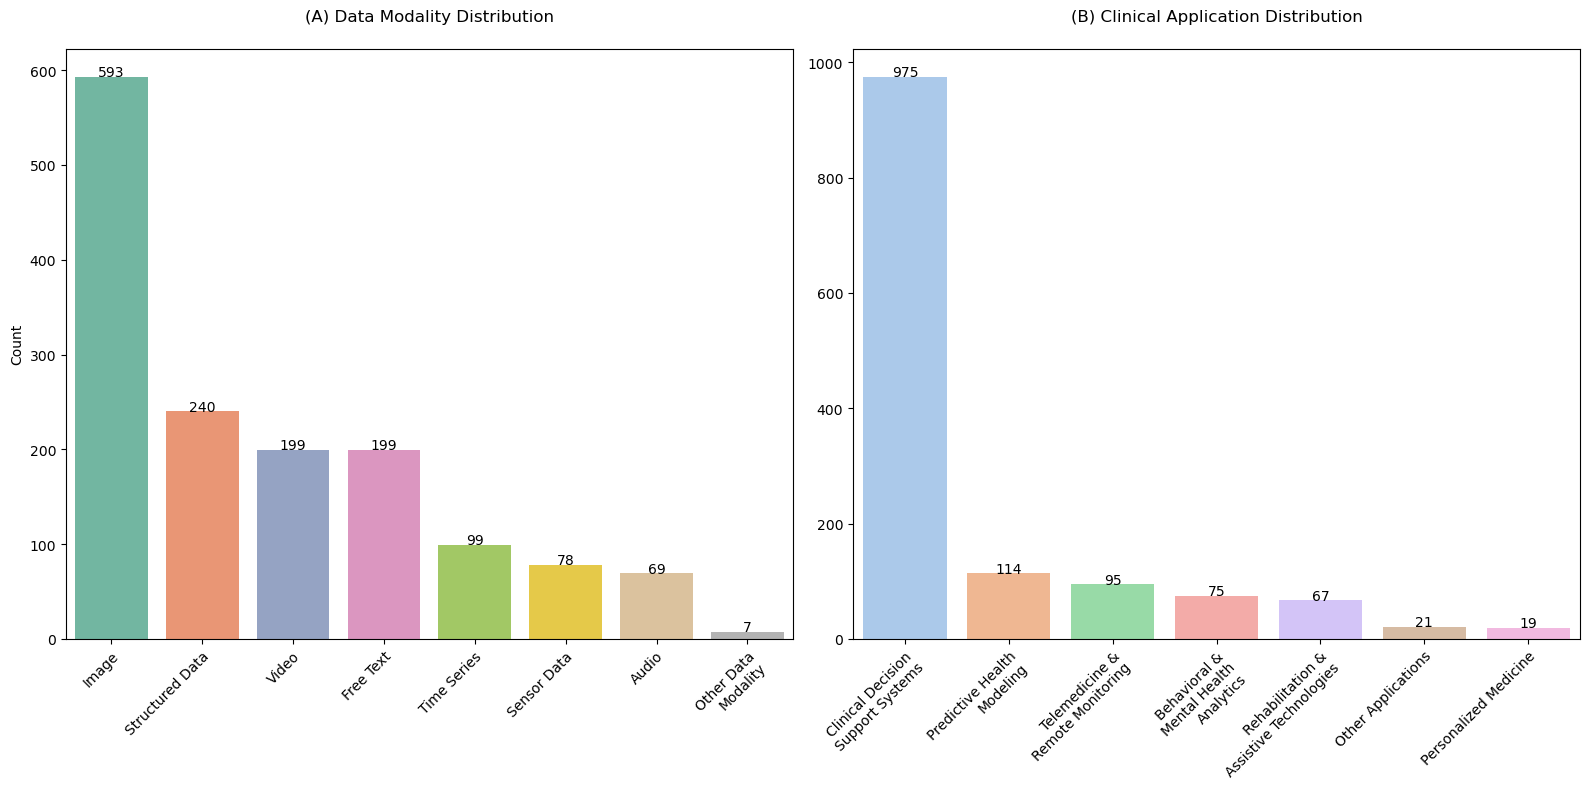

In [16]:
# Count values
modality_counts = df_modality["Data Modality"].value_counts()
application_counts = df_application["AI Application"].value_counts()

def wrap_words(label, words_per_line=2):
    words = str(label).split()
    if len(words) <= words_per_line:
        return str(label)
    return "\n".join(
        " ".join(words[i:i + words_per_line])
        for i in range(0, len(words), words_per_line)
    )

modality_labels = [wrap_words(x, 2) for x in modality_counts.index]
application_labels = [wrap_words(x, 2) for x in application_counts.index]

# Set a special color palette
palette1 = sns.color_palette("Set2", len(modality_counts))
palette2 = sns.color_palette("pastel", len(application_counts))

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# First plot: Data Modality Distribution
sns.barplot(x=modality_labels, y=modality_counts.values, palette=palette1, ax=axes[0])
axes[0].set_ylabel("Count")
axes[0].set_title("(A) Data Modality Distribution", pad=20)
axes[0].tick_params(axis="x", labelrotation=0)
axes[0].set_xticklabels(modality_labels, rotation=45, ha="right", rotation_mode="anchor")

for i, value in enumerate(modality_counts.values):
    axes[0].text(i, value + 0.8, str(value), ha="center", fontsize=10)

# Second plot: AI Application Distribution
sns.barplot(x=application_labels, y=application_counts.values, palette=palette2, ax=axes[1])
axes[1].set_title("(B) Clinical Application Distribution", pad=20)
axes[1].tick_params(axis="x", labelrotation=0)
axes[1].set_xticklabels(application_labels, rotation=45, ha="right", rotation_mode="anchor")

for i, value in enumerate(application_counts.values):
    axes[1].text(i, value + 0.8, str(value), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("./Figure/Figure_3", dpi=300, bbox_inches="tight")
plt.show()


## Clinical Trial Files

In [17]:

trials = pd.concat([pd.read_csv("./Data/Trial Files/AI_trials_1_26_26.csv"),
           pd.read_csv("./Data/Trial Files/AI_trials_1_5_26.csv")]).drop_duplicates(subset=["NCT Number"])

In [18]:
trials = trials[trials["NCT Number"].isin(comparative_study_ID)]

## Conditions

In [19]:
conditions = pd.concat([trials["NCT Number"], trials["Conditions"].str.split("|", expand=True)], axis=1)

In [20]:
conditions = pd.melt(conditions, id_vars=['NCT Number'], var_name='type', value_name='Conditions')
conditions = conditions.drop(columns=["type"]).dropna()
conditions["Conditions"] = conditions["Conditions"].str.strip().str.lower()

substrings = ["artificial intelligence", "machine learning", "deep learning"]
conditions = conditions[~conditions["Conditions"].apply(lambda x: any(sub in x for sub in substrings))]

In [21]:
mapped_conditions = pd.read_csv("./Data/Processed_data/mapped_AI_conditions_1_26_26.csv")


In [22]:
mapped_conditions = mapped_conditions.drop(columns=["Conditions_mapped_concept"])
mapped_conditions.columns = ["NCT Number",	"Conditions",	"CUI code",	"UMLS Official Name"]

In [23]:
conditions = mapped_conditions.copy()

## Mesh Condition

In [24]:
with open("./Data/Trial Files/AI_trials_1_14_26.json") as f:
    raw_trials = json.load(f)

raw_trials = [i for i in raw_trials \
              if i["protocolSection"]["identificationModule"]["nctId"] in comparative_study_ID.values]

In [25]:
no_mesh = 0
mesh_conditions = {}
all_mesh = pd.DataFrame(columns = ["NCT Number", "Mesh"])

for i in raw_trials:
    trial_id = i["protocolSection"]["identificationModule"]["nctId"]
    
    try:
        for j in i["derivedSection"]["conditionBrowseModule"]["meshes"]:
            all_mesh.loc[len(all_mesh)] = [trial_id, j["term"]]    
    except Exception as e:
        no_mesh+=1

        
print(f"About {round(no_mesh/len(raw_trials), 4)*100}% of trials don't have mesh condition")

About 26.36% of trials don't have mesh condition


In [26]:


# 1. Your Input List (Simulating a Value Counts Series)
mesh_terms = [
    'Colonic Polyps', 'Breast Neoplasms', 'Colorectal Neoplasms',
    'Diabetic Retinopathy', 'Disease', 'Prostatic Neoplasms',
    'Anxiety Disorders', 'Diabetes Mellitus', 'Lung Neoplasms',
    'Diabetes Mellitus, Type 2', 'Colonic Neoplasms', 'Neoplasms',
    'Heart Failure', 'Atrial Fibrillation', 'Adenoma', 'Depression',
    'Stomach Neoplasms', 'Coronary Artery Disease', 'Stroke', 'COVID-19'
]


# ---------------------------------------------------------
# 2. Define The Cleaning Logic
# ---------------------------------------------------------

# A. Terms to Drop (Too broad/vague)
drop_list = ['Disease', 'Neoplasms']

# B. Terms to Rename & Group (The Dictionary)
rename_map = {
    # -- Cancer Normalization --
    'Colorectal Neoplasms': 'Colorectal Cancer',
    'Colonic Neoplasms':    'Colorectal Cancer',  # Merge into Colorectal
    'Breast Neoplasms':     'Breast Cancer',
    'Prostatic Neoplasms':  'Prostate Cancer',
    'Lung Neoplasms':       'Lung Cancer',
    'Stomach Neoplasms':    'Stomach Cancer',
    
    # -- Benign / Polyp Normalization --
    'Colonic Polyps':       'Colon Polyps / Adenoma',
    'Adenoma':              'Colon Polyps / Adenoma', # Merge Generic Adenoma here
    
    # -- Diabetes Normalization --
    'Diabetes Mellitus, Type 2': 'Diabetes Mellitus', # Merge Subtype into Parent
    
}

# ---------------------------------------------------------
# 3. Apply the Transformation
# ---------------------------------------------------------

# Step 1: Drop the garbage terms
all_mesh = all_mesh[~all_mesh['Mesh'].isin(drop_list)]

# Step 2: Rename the index (Grouping happens here automatically if using groupby)
# Note: Just renaming the index doesn't sum the counts yet.
all_mesh = all_mesh.replace(rename_map)



In [27]:
top_k = 10

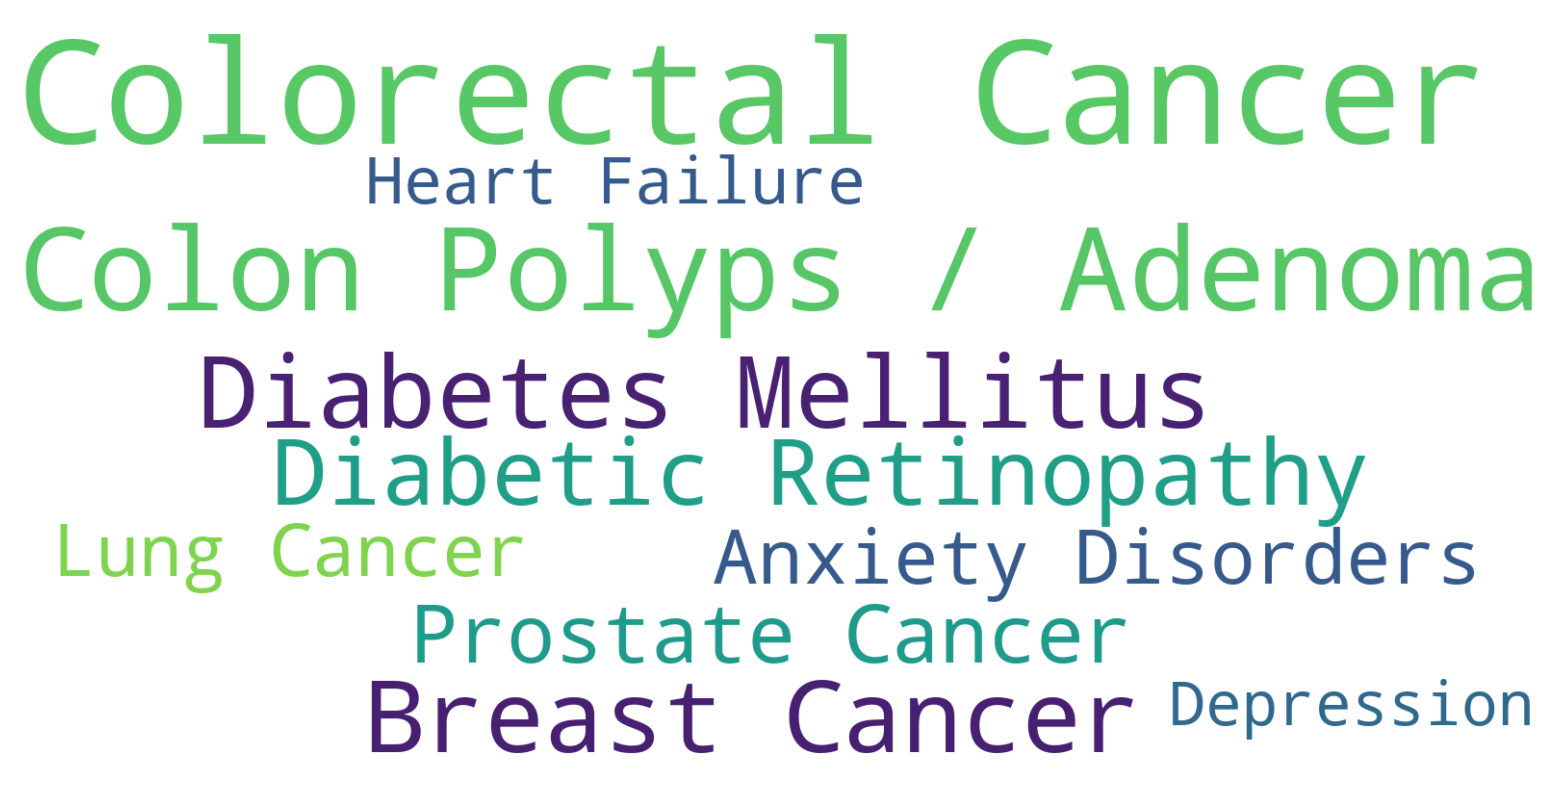

In [28]:
## Top Conditions mapped to Mesh
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    prefer_horizontal=1.0,  # Force horizontal text
    min_font_size=10,
    max_font_size=150,
    random_state=42  # For reproducibility
)

# Generate word cloud
wordcloud.generate_from_frequencies(all_mesh["Mesh"].value_counts()[:top_k])

# Create figure
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

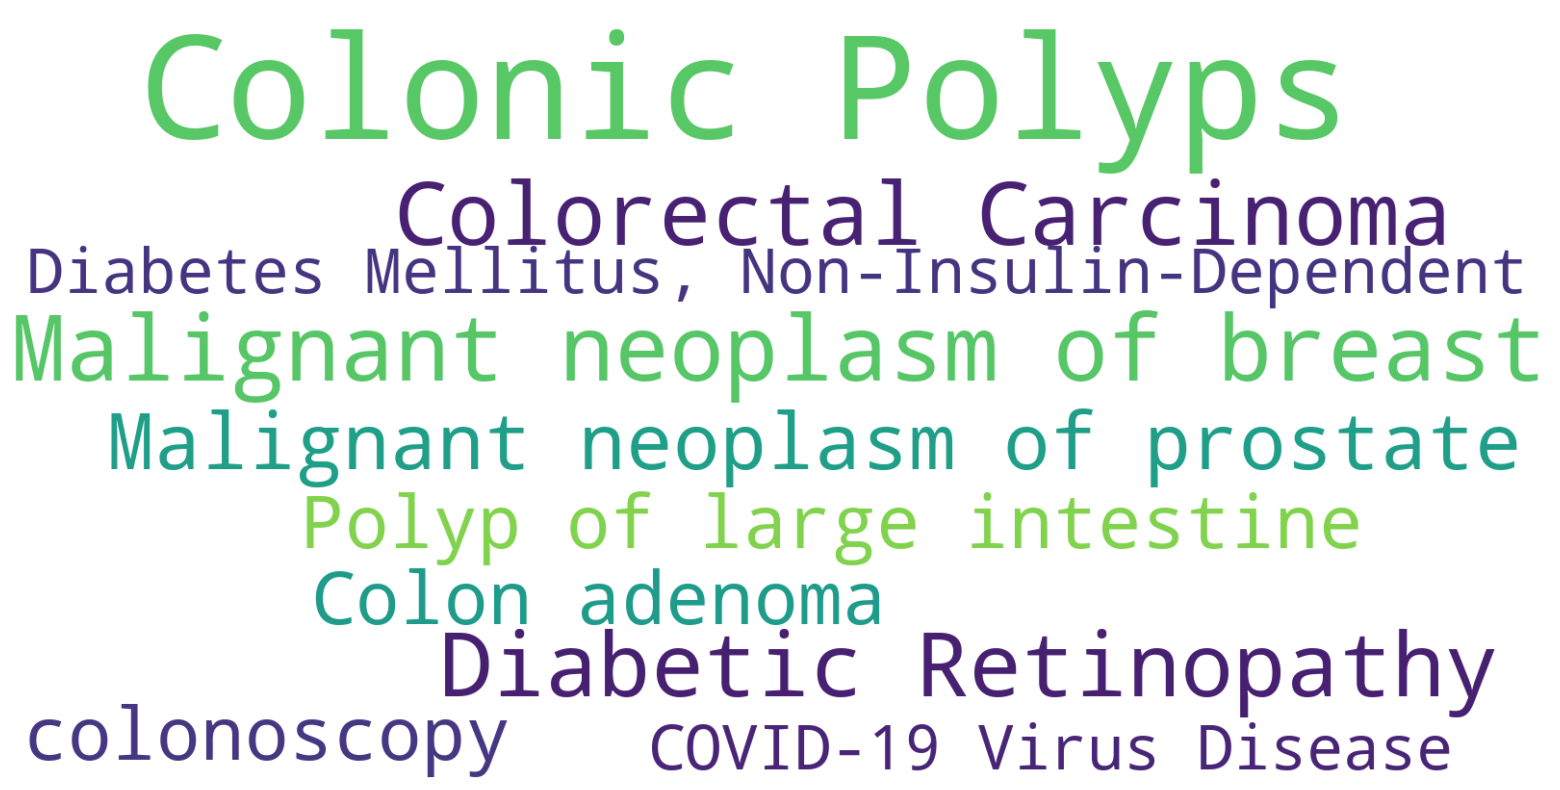

In [29]:
## Top 20 Conditions mapped to UMLS
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    prefer_horizontal=1.0,  # Force horizontal text
    min_font_size=10,
    max_font_size=150,
    random_state=42  # For reproducibility
)

# Generate word cloud
wordcloud.generate_from_frequencies(conditions["UMLS Official Name"].value_counts()[:top_k])

# Create figure
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Cleaned Condition Grouping

In [30]:
phecode = pd.read_csv("./Data/Processed_data/final_phecode_clean.csv")
all_umls_phecode = pd.read_csv("./Data/Processed_data/all_umls_phecode.csv")\
    .drop_duplicates(subset=["Conditions_mapped_concept_id", "Phecode Category"])


In [31]:
all_phecode_conditions = conditions.merge(all_umls_phecode, left_on="CUI code", right_on="Conditions_mapped_concept_id",
                 how="left")

In [32]:
not_mapped = all_phecode_conditions["PhecodeString"].isna().sum()

all_phecode_conditions["Not NA Flag"] = np.where(all_phecode_conditions["PhecodeString"].isna(),
                                                 0,
                                                 1)

not_mapped_percent = not_mapped/all_phecode_conditions.shape[0]

print(f"{not_mapped} ({round(not_mapped_percent*100, 2)}%) concetps not mapped.")


1095 (39.77%) concetps not mapped.


In [33]:


all_phecode_conditions["PhecodeString"] = np.where(all_phecode_conditions["PhecodeString"].isna(), 
         all_phecode_conditions["UMLS Official Name"],
         all_phecode_conditions["PhecodeString"])

all_phecode_conditions["PhecodeString"] = all_phecode_conditions["PhecodeString"].str.lower()

items_to_drop = [
    'Neoplasm of unspecified nature of digestive system',
    'Other perinatal conditions of fetus or newborn',
    'Cancer, suspected or other',
    'Other tests',
    'Other disorders of intestine',
    'Other forms of chronic heart disease',
    'Other disorders of liver',
    'Ill-defined descriptions and complications of heart disease',
    "Biomedical Research",
    # "Students, Nursing",
    # "Colonoscopy",
    # "Abnormal Heart Sounds",
    # "Decision Making",
    "Symptoms Involving Female Genital Tract",
    'Benign Neoplasm Of Unspecified Sites',
    'First Episode',
    # 'large language models',
    # 'education, medical',
    # "Burnout, Professional",
    "Client Satisfaction",
    # "Informing Patient Of Diagnosis",

]
items_to_drop = [i.lower() for i in items_to_drop]

all_phecode_conditions = all_phecode_conditions[~all_phecode_conditions['PhecodeString'].isin(items_to_drop)]

rename_map = {
    'delirium dementia and amnestic and other cognitive disorders': 'dementia / cognitive impairment',
    'develomental delays and disorders':                            'autism / developmental disorders',
    
    'ischemic heart disease':                                       'coronary artery disease',
    'cancer of prostate':                                           'prostate cancer', 
    'cancer of mouth':                                              'oral cancer',
    'septicemia':                                                   'sepsis',
    'sepsis and sirs':                                              'sepsis',
    'covid-19 virus disease':                                       'covid-19',
    'congestive heart failure; nonhypertensive':                    'heart failure',
    'colon adenoma':                                                'colon polyps / adenoma',
    'benign neoplasm of colon':                                     'colon polyps / adenoma',
    'cardiac dysrhythmias':                                         'arrhythmia',
    'anxiety, phobic and dissociative disorders':                   'anxiety disorders',
    'infection/inflammation of internal prosthetic device; implant; and graft': 'implant infection',
    'colorectal cancer': 'Colorectal Carcinoma'
}
all_phecode_conditions['PhecodeString'] = all_phecode_conditions['PhecodeString'].replace(rename_map).str.title()


## Hierachycal Distribution

### Top Conditions In Each AI Application 

In [34]:

select_k = 3
application_conditions = pd.DataFrame()

for app in df_application["AI Application"].unique():
    selected_ID = df_application.loc[df_application["AI Application"]==app, "Study ID"]
    top_conditions = all_phecode_conditions[all_phecode_conditions["NCT Number"].isin(selected_ID)]\
    ["PhecodeString"].value_counts()[:select_k].index.tolist()
    
    if len(top_conditions)<select_k:
        top_conditions += ["" for i in range(select_k-len(top_conditions))]
    application_conditions[app] = (top_conditions)

### Top Conditions In Each AI Data Modality

In [35]:
select_k = 3
modality_conditions = pd.DataFrame()

for modality in df_modality["Data Modality"].unique():
    selected_ID = df_modality.loc[df_modality["Data Modality"]==modality, "Study ID"]
    top_conditions = all_phecode_conditions[all_phecode_conditions["NCT Number"].isin(selected_ID)]\
    ["PhecodeString"].value_counts()[:select_k].index.tolist()
    if len(top_conditions) < select_k:
        top_conditions += ["-"] * (select_k - len(top_conditions))
    modality_conditions[modality] = top_conditions

## Top conditions in Data Modality and Application

In [36]:
df_modality_condition = df_modality.copy()
df_application_condition = df_application.copy()

df_modality_condition["value"] = 1
df_application_condition["value"] = 1


In [37]:
df_modality_condition = df_modality_condition.pivot_table(index='Study ID', columns='Data Modality', values='value', fill_value=0).reset_index()
df_application_condition = df_application_condition.pivot_table(index='Study ID', columns='AI Application', values='value', fill_value=0).reset_index()

In [38]:
df_combined_mod_app = df_modality_condition.merge(df_application_condition, on="Study ID")

In [39]:
combined_condition_ID = {}
for mod in df_modality["Data Modality"].unique():
    for app in df_application["AI Application"].unique():
        key = f"{mod}_{app}"
        IDs = df_combined_mod_app.loc[df_combined_mod_app[mod]+df_combined_mod_app[app]==2, "Study ID"]
        combined_condition_ID[key] = IDs.values

In [40]:
top_k = 3

df_combined_condition_UMLS = pd.DataFrame("", index = df_modality["Data Modality"].unique(), columns=df_application["AI Application"].unique())
df_combined_condition_mesh = pd.DataFrame("", index = df_modality["Data Modality"].unique(), columns=df_application["AI Application"].unique())

for key, IDs in combined_condition_ID.items():
    row_name, col_name = key.split("_")
    top_conditions_UMLS = all_phecode_conditions.loc[all_phecode_conditions["NCT Number"].isin(IDs), "PhecodeString"].value_counts()[:top_k].index.tolist()
    top_conditions_UMLS = ["- " + i for i in top_conditions_UMLS]
    top_conditions_UMLS = "\n".join(top_conditions_UMLS)
    df_combined_condition_UMLS.loc[row_name, col_name] = top_conditions_UMLS
    
    top_conditions_mesh = all_mesh.loc[all_mesh["NCT Number"].isin(IDs), "Mesh"].value_counts()[:top_k].index.tolist()
    top_conditions_mesh = ["- " + i for i in top_conditions_mesh]
    top_conditions_mesh = "\n".join(top_conditions_mesh)
    df_combined_condition_mesh.loc[row_name, col_name] = top_conditions_mesh

    
df_UMLS_styled = df_combined_condition_UMLS.style.set_properties(**{'white-space': 'pre-wrap'})

df_mesh_styled = df_combined_condition_mesh.style.set_properties(**{'white-space': 'pre-wrap'})



/var/folders/l7/ld27cn8d2n5bk1qz5h_nydyw0000gn/T/ipykernel_49803/343284480.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


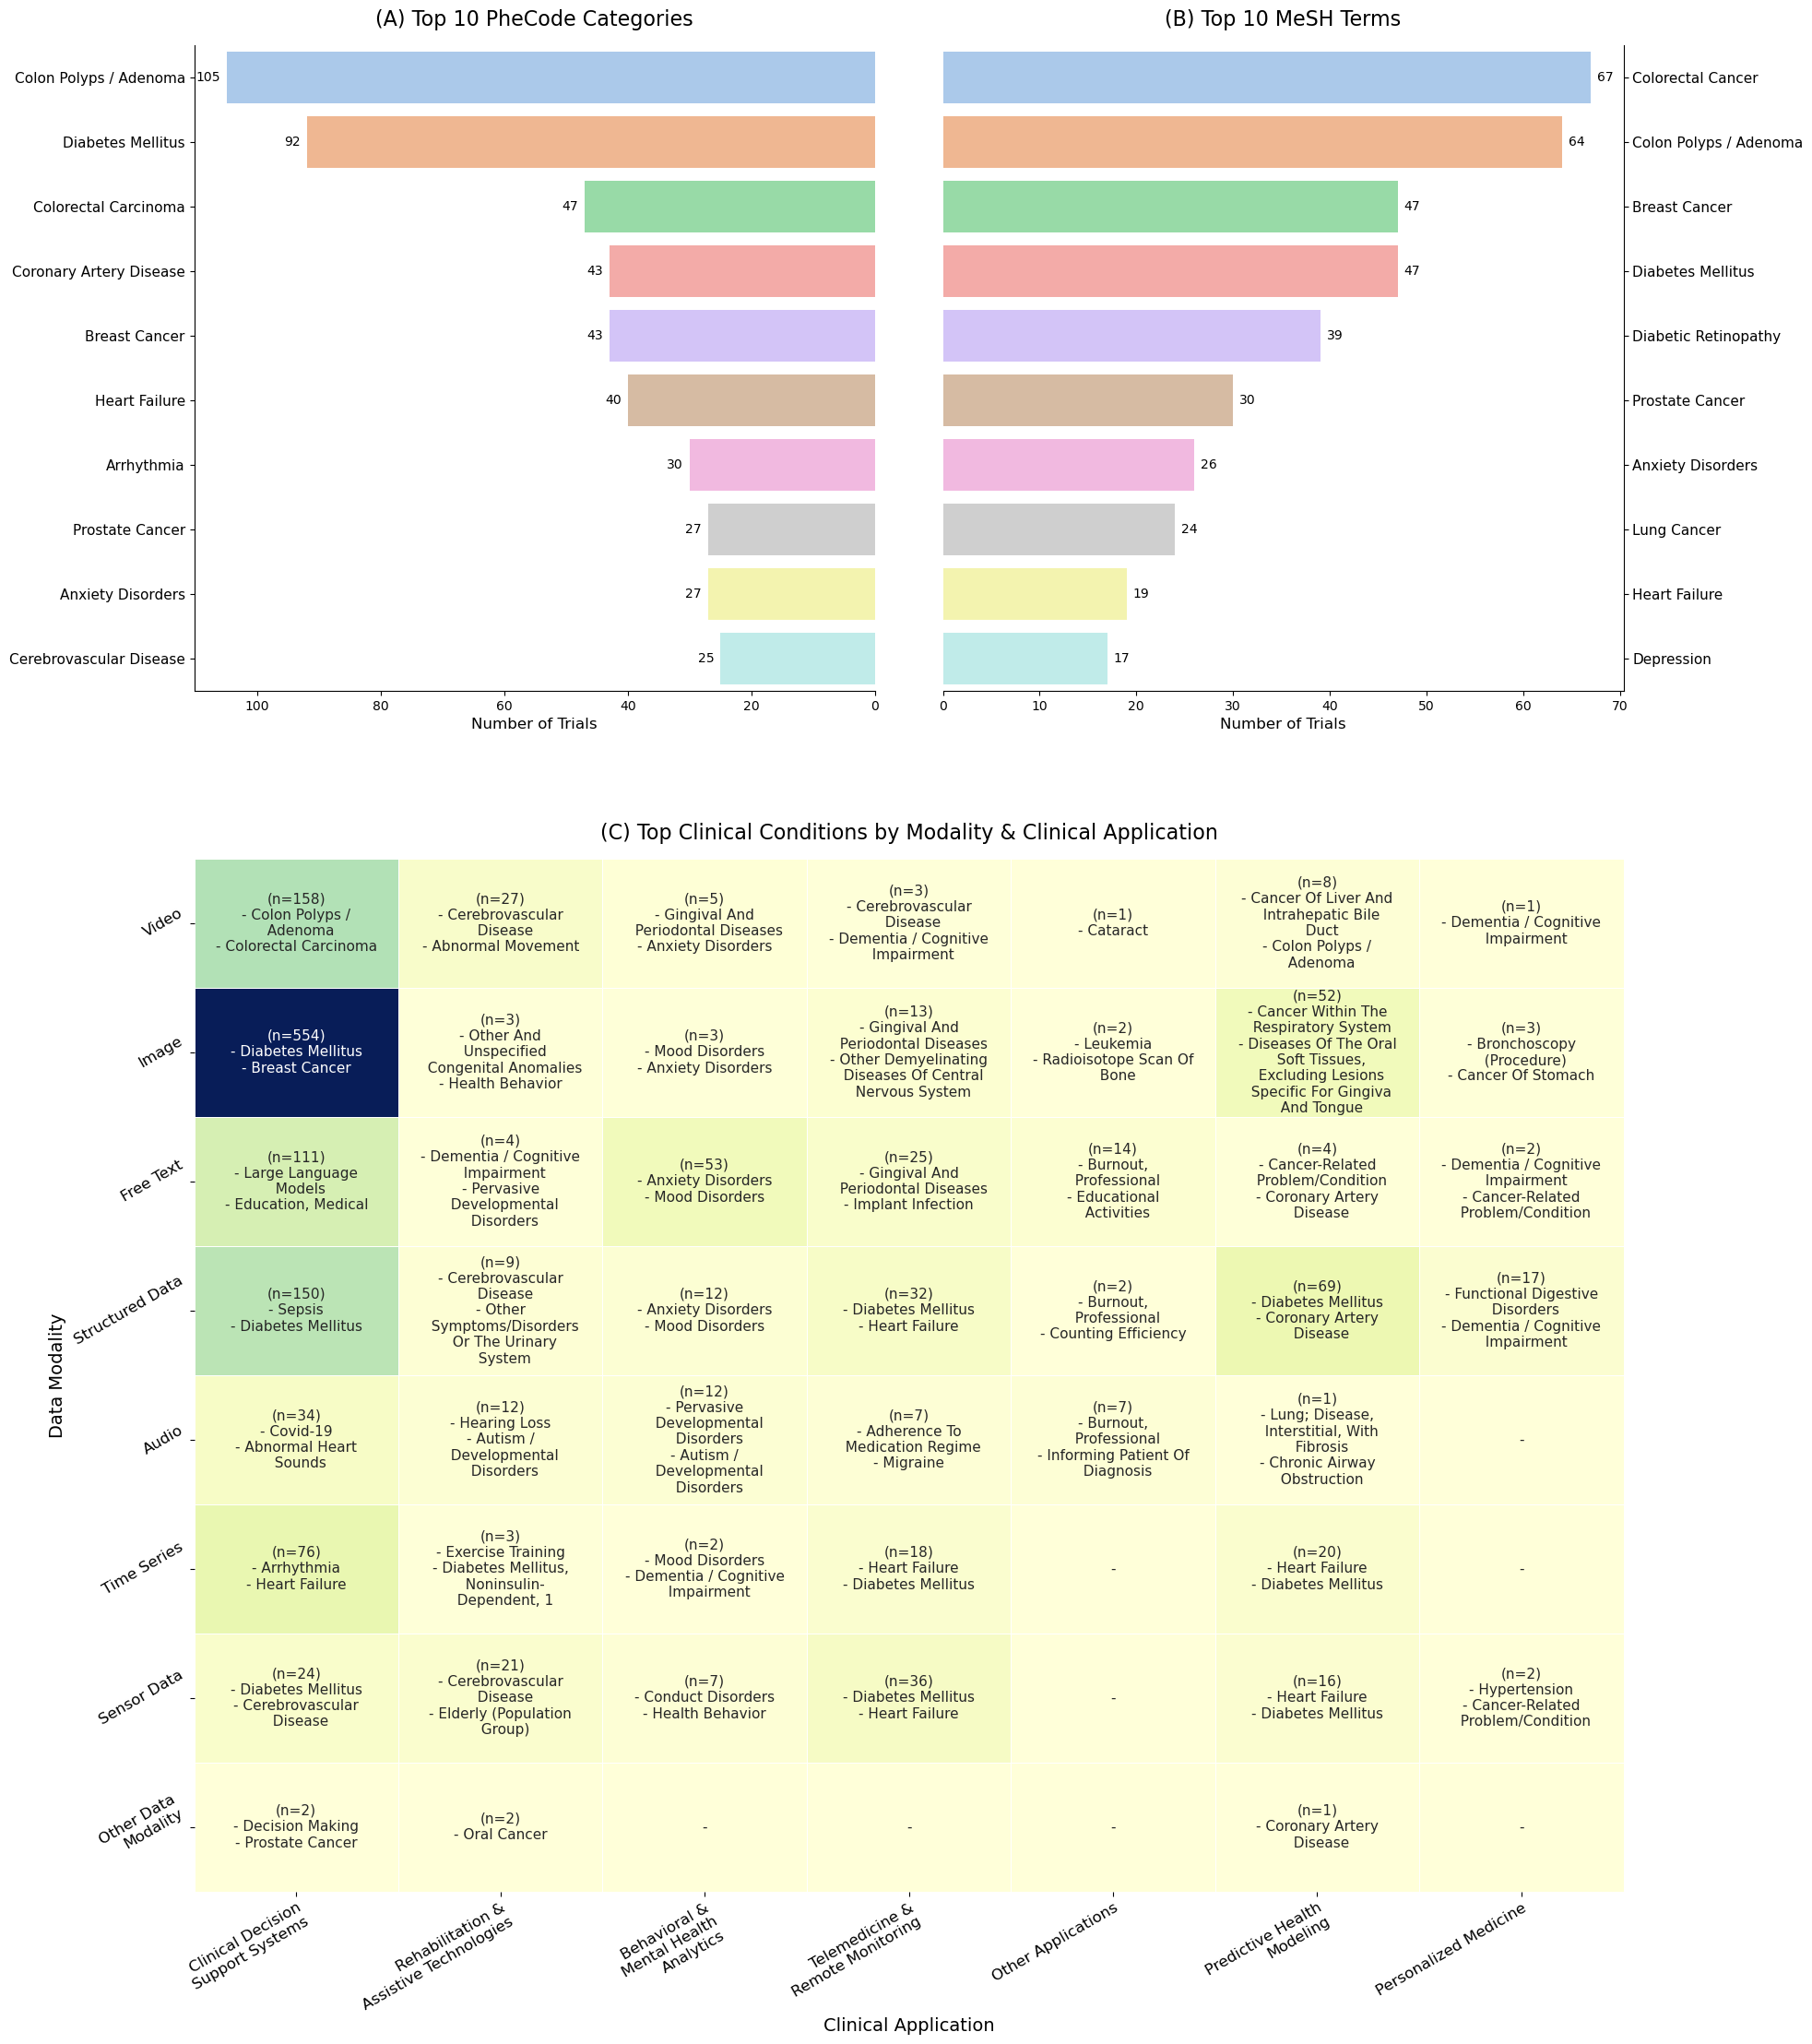

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import textwrap

def wrap_if_more_than_two_words(label, words_per_line=2):
    words = str(label).split()
    if len(words) <= 2:
        return str(label)
    return "\n".join(
        " ".join(words[i:i+words_per_line])
        for i in range(0, len(words), words_per_line)
    )

# --- 1. SETUP FIGURE AND GRIDSPEC ---
fig = plt.figure(figsize=(20, 26)) 

# Adjust wspace: 
# wspace=0.1 -> Brings the plots closer together (back-to-back look)
# hspace=0.3 -> Vertical space between Row 1 and Row 2
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6], wspace=0.1, hspace=0.2)

# ==========================================
# ROW 1: MIRROR BAR CHART (Labels on Outer Edges)
# ==========================================

# --- Prepare Data ---

top_k = 10
umls_top = all_phecode_conditions["PhecodeString"].value_counts()[:top_k]
mesh_top = all_mesh["Mesh"].value_counts().head(top_k)

ax1 = fig.add_subplot(gs[0, 0]) # Top Left
ax2 = fig.add_subplot(gs[0, 1]) # Top Right

palette_umls = sns.color_palette("pastel", len(umls_top))
palette_mesh = sns.color_palette("pastel", len(mesh_top))

# --- LEFT PLOT (UMLS) ---
sns.barplot(x=umls_top.values, y=umls_top.index, ax=ax1, palette=palette_umls)
ax1.set_title(f"(A) Top {top_k} PheCode Categories", fontsize=16, pad=15)
ax1.set_xlabel("Number of Trials", fontsize=12)

# KEY CHANGES FOR LEFT PLOT:
# 1. Invert x-axis so bars grow to the left
ax1.invert_xaxis() 
# 2. Keep labels on the LEFT (Default) so they don't overlap the center
ax1.yaxis.tick_left()
# 3. Clean up spines
ax1.spines['right'].set_visible(False) # Remove center spine
ax1.spines['top'].set_visible(False)
ax1.set_yticklabels(umls_top.index, fontsize=11)

# Add counts inside/near bars
for i, v in enumerate(umls_top.values):
    # Place text slightly to the LEFT of the bar end (negative offset because axis is inverted)
    ax1.text(v + (max(umls_top.values)*0.01), i, str(v), ha='right', va='center', fontsize=10)

# --- RIGHT PLOT (MeSH) ---
sns.barplot(x=mesh_top.values, y=mesh_top.index, ax=ax2, palette=palette_mesh)
ax2.set_title(f"(B) Top {top_k} MeSH Terms", fontsize=16, pad=15)
ax2.set_xlabel("Number of Trials", fontsize=12)

# KEY CHANGES FOR RIGHT PLOT:
# 1. Move labels to the RIGHT side (Far edge)
ax2.yaxis.tick_right()
# 2. Align labels to the left so they stick to the axis
ax2.yaxis.set_label_position("right") 
# 3. Clean up spines
ax2.spines['left'].set_visible(False) # Remove center spine
ax2.spines['top'].set_visible(False)
ax2.set_yticklabels(mesh_top.index, fontsize=11)

# Add counts inside/near bars
for i, v in enumerate(mesh_top.values):
    ax2.text(v + (max(mesh_top.values)*0.01), i, str(v), ha='left', va='center', fontsize=10)


# ==========================================
# ROW 2: DETAILED HEATMAP (Unchanged)
# ==========================================

# --- Prepare Data ---
df_modality_condition = df_modality.copy()
df_application_condition = df_application.copy()
df_modality_condition["value"] = 1
df_application_condition["value"] = 1

df_modality_condition = df_modality_condition.pivot_table(index='Study ID', columns='Data Modality', values='value', fill_value=0).reset_index()
df_application_condition = df_application_condition.pivot_table(index='Study ID', columns='AI Application', values='value', fill_value=0).reset_index()
df_combined_mod_app = df_modality_condition.merge(df_application_condition, on="Study ID")

rows_hm = df_modality["Data Modality"].unique()
cols_hm = df_application["AI Application"].unique()

df_text_UMLS = pd.DataFrame("", index=rows_hm, columns=cols_hm)
df_counts = pd.DataFrame(0, index=rows_hm, columns=cols_hm)

top_k = 2
wrap_width = 20

for mod in rows_hm:
    for app in cols_hm:
        IDs = df_combined_mod_app.loc[df_combined_mod_app[mod] + df_combined_mod_app[app] == 2, "Study ID"]
        count = len(IDs)
        df_counts.loc[mod, app] = count
        
        if count > 0:
            top_conditions = all_phecode_conditions.loc[all_phecode_conditions["NCT Number"].isin(IDs), "PhecodeString"].value_counts()[:top_k].index.tolist()
            wrapped_items = []
            for item in top_conditions:
                wrapped_item = textwrap.fill(item, width=wrap_width)
                formatted_item = "- " + wrapped_item.replace("\n", "\n  ")
                wrapped_items.append(formatted_item)
            
            if wrapped_items:
                condition_text = "\n".join(wrapped_items)
                final_label = f"(n={count})\n{condition_text}"
                df_text_UMLS.loc[mod, app] = final_label
        else:
            df_text_UMLS.loc[mod, app] = "-"

df_text_UMLS = df_text_UMLS.replace("", "-")
# --- Plot Heatmap ---
ax3 = fig.add_subplot(gs[1, :]) 

heatmap = sns.heatmap(df_counts, 
            annot=df_text_UMLS, 
            fmt='', 
            cmap='YlGnBu', 
            linewidths=0.5,
            ax=ax3, 
            # cbar_kws={'label': 'Number of Shared Studies'},
            cbar=False,
            annot_kws={"size": 11, "va": "center"}) 

# cbar = heatmap.collections[0].colorbar
# cbar.set_label('Number of Shared Studies', fontsize=14)
# cbar.ax.tick_params(labelsize=12)

x_labels_wrapped = [wrap_if_more_than_two_words(t.get_text(), 2) for t in ax3.get_xticklabels()]
y_labels_wrapped = [wrap_if_more_than_two_words(t.get_text(), 2) for t in ax3.get_yticklabels()]

ax3.set_title(f"(C) Top Clinical Conditions by Modality & Clinical Application", fontsize=16, pad=15)
ax3.set_xlabel("Clinical Application", fontsize=14)
ax3.set_ylabel("Data Modality", fontsize=14)
ax3.set_xticklabels(x_labels_wrapped, rotation=30, ha='right', fontsize=12, rotation_mode='anchor')
ax3.set_yticklabels(y_labels_wrapped, rotation=30, fontsize=12)

# --- FINALIZE ---
plt.tight_layout()
plt.savefig("./Figure/Figure_5.png", dpi=300, bbox_inches='tight')
plt.show()

### AI Data Modality to AI Application 

In [42]:
modality_appliation = df_modality.merge(df_application).drop(columns=["Study ID"])

In [43]:
nodes = modality_appliation["Data Modality"].unique().tolist() + \
modality_appliation["AI Application"].unique().tolist()

node_index = range(len(nodes))

In [44]:
modality_appliation = modality_appliation.groupby(["Data Modality", "AI Application"]).size().reset_index(name="value")


In [45]:
mapping_dict = dict(zip(nodes, node_index))
mapping_dict

for col in ["Data Modality", "AI Application"]:
    modality_appliation[col] = modality_appliation[col].map(mapping_dict)

if modality_appliation[["Data Modality", "AI Application"]].isnull().any().any():
    raise ValueError("Found unmapped node labels in Sankey source/target columns.")

modality_appliation[["Data Modality", "AI Application"]] = modality_appliation[["Data Modality", "AI Application"]].astype(int)


In [46]:
import plotly.graph_objects as go
import plotly.express as px


def to_rgba(color, alpha=0.35):
    color = color.strip()
    if color.startswith("rgba("):
        values = [v.strip() for v in color[5:-1].split(",")]
        if len(values) != 4:
            raise ValueError(f"Invalid rgba color: {color}")
        return f"rgba({values[0]},{values[1]},{values[2]},{alpha})"
    if color.startswith("rgb("):
        values = [v.strip() for v in color[4:-1].split(",")]
        if len(values) != 3:
            raise ValueError(f"Invalid rgb color: {color}")
        return f"rgba({values[0]},{values[1]},{values[2]},{alpha})"
    if color.startswith("#"):
        hex_color = color.lstrip("#")
        if len(hex_color) == 3:
            hex_color = "".join(ch * 2 for ch in hex_color)
        if len(hex_color) != 6:
            raise ValueError(f"Invalid hex color: {color}")
        r = int(hex_color[0:2], 16)
        g = int(hex_color[2:4], 16)
        b = int(hex_color[4:6], 16)
        return f"rgba({r},{g},{b},{alpha})"
    raise ValueError(f"Unsupported color format: {color}")


links = []
for _, row in modality_appliation.iterrows():
    path = {}
    path["source"] = int(row["Data Modality"])
    path["target"] = int(row["AI Application"])
    path["value"] = row["value"]
    links.append(path)

# Use one unique color per left-side modality node, and apply that color
# to all flows originating from that modality.
num_modalities = modality_appliation["Data Modality"].nunique()
palette = px.colors.qualitative.Set3
modality_color_map = {
    modality_idx: to_rgba(palette[i % len(palette)], alpha=0.75)
    for i, modality_idx in enumerate(sorted(modality_appliation["Data Modality"].unique()))
}
link_colors = [modality_color_map[link["source"]] for link in links]

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes,
    ),
    link=dict(
        source=[link["source"] for link in links],
        target=[link["target"] for link in links],
        value=[link["value"] for link in links],
        color=link_colors,
    ),
))

# Display the plot
fig.update_layout(
    #title_text="AI Data Modality to Clinical Application",
                   font_size=13, width = 800, height = 800)
fig.show()
# fig.write_html("./AI Data Modality to AI Application.html")

fig.write_image("./Figure/Figure_4.svg")

# fig.write_image(
#     "AI_Data_Modality_to_AI_Application_300dpi.png",
#     width=2400,
#     height=2400,
#     scale=1
# )


## All New Trials by Year

In [47]:

date_col = "Start Date"

all_year_trial = pd.read_csv("./Data/Processed_data/all_year_trial_4_27_26.csv").dropna(subset=[date_col])

all_year_trial[date_col] = all_year_trial[date_col].str[:4]
all_year_trial[date_col] = all_year_trial[date_col].astype(int)


new_trials = all_year_trial[(all_year_trial["Start Date"]>=2012) & (all_year_trial["Start Date"]<=2025)]\
    [date_col].value_counts().sort_index().reset_index()

new_trials.columns = ["Year", "Number of Trials"]
new_trials.to_excel("./Data/Processed_data/Number of New Trials by Year.xlsx", index=False)



## Increasing Rate

In [48]:
new_trails_year = pd.read_excel("./Data/Processed_data/Number of New Trials by Year.xlsx")
new_trails_year["Year"] = new_trails_year["Year"].astype(str)

new_trails_year["rate of increase (%)"] = round(new_trails_year["Number of Trials"].pct_change()*100,2)

start_date_year = trials["Start Date"].str[:4].value_counts().sort_index().reset_index()
start_date_year["AI rate of increase (%)"] = round(start_date_year["Start Date"].pct_change()*100,2)

new_trails_year = new_trails_year.merge(start_date_year, left_on = "Year", right_on="index").drop(columns=["index"])
new_trails_year.rename(columns={"Start Date": "Number of AI Trials"}, inplace=True)
new_trails_year.loc[0,"AI rate of increase (%)"]=np.nan

new_trails_year["AI Percentage"] = round(new_trails_year["Number of AI Trials"]/new_trails_year["Number of Trials"]*100, 2)

new_trails_year["AI Percentage rate of increase (%)"] = round(new_trails_year["AI Percentage"].pct_change()*100, 2)

## Location Heatmap

In [49]:

with open("./Data/Trial Files/AI_trials_1_14_26.json") as f:
    raw_trials = json.load(f)

raw_trials = [i for i in raw_trials \
              if i["protocolSection"]["identificationModule"]["nctId"] in comparative_study_ID.values]

In [50]:
no_loc = 0
locations = {}
all_loc = pd.DataFrame(columns = ["NCT Number", "location", "lat", "lon"])

for i in raw_trials:
    try:
        trial_id = i["protocolSection"]["identificationModule"]["nctId"]
        for j in i["protocolSection"]["contactsLocationsModule"]["locations"]:
            all_loc.loc[len(all_loc)] = [trial_id, j["country"], j["geoPoint"]["lat"], j["geoPoint"]["lon"]]

        
    except Exception as e:
        no_loc+=1

all_loc["intensity"] = 1

print(f"About {round(no_loc/len(raw_trials), 4)*100}% of trials don't have locations")

About 10.620000000000001% of trials don't have locations


## Integrated Figure

In [51]:
def plot_year_increasing_on_axis(ax_bar, count_col, increase_col, second_increase_col, title, off_set_1_positive, off_set_1_negative, lower_y=1.2, upper_y=1.3, y_label="Count"):
    years = new_trails_year["Year"]
    counts = new_trails_year[count_col]
    
    # Extract both growth rates (skipping the first year to match x_coords)
    growth_rates = new_trails_year[increase_col][1:]
    growth_rates_all = new_trails_year[second_increase_col][1:]
    
    palette = sns.color_palette("pastel", len(years))

    # **Bar Chart (Left Axis)**
    sns.barplot(x=years, y=counts, palette=palette, ax=ax_bar)
    ax_bar.set_title(title, fontsize=14)
    ax_bar.set_xlabel("Year")
    ax_bar.set_ylabel(y_label)
    ax_bar.set_ylim(0, 1.2 * max(counts))

    for i, value in enumerate(counts):
        ax_bar.text(i, 1.01*value, str(value), ha='center', fontsize=8)

    # **Line Chart (Right Axis)**
    ax_line = ax_bar.twinx()  
    x_coords = range(1, len(years)) 
    
    # Plot both lines with labels for the legend
    ax_line.plot(x_coords, growth_rates, marker='o', linestyle='--', color='red', label='AI Trials growth rate')
    ax_line.plot(x_coords, growth_rates_all, marker='o', linestyle='--', color='gray', label='All trials growth rate')
    
    ax_line.set_ylabel("Growth Rate (%)")
    
    # Adjust ylim based on the min and max of BOTH lines
    min_growth = min(min(growth_rates), min(growth_rates_all))
    max_growth = max(max(growth_rates), max(growth_rates_all))
    ax_line.set_ylim(min_growth * lower_y, max_growth * upper_y)

    # ==========================================
    # Add text labels for both lines
    # ==========================================
    for x, y_red, y_gray in zip(x_coords, growth_rates, growth_rates_all):
        
        # Red line label (Upper Right)
        # ha='left' and x+0.1 pushes it to the right; va='bottom' pushes it up
        ax_line.text(x + 0.1, y_red + off_set_1_positive, f"{y_red:.1f}%", 
                     ha='left', va='bottom', fontsize=10, color="red")
        
        # Gray line label (Lower Right)
        # ha='left' and x+0.1 pushes it to the right; va='top' pushes it down
        ax_line.text(x + 0.1, y_gray - off_set_1_negative, f"{y_gray:.1f}%", 
                     ha='left', va='top', fontsize=10, color="gray")

    # Add the legend in the upper left
    ax_line.legend(loc='upper left')



/var/folders/l7/ld27cn8d2n5bk1qz5h_nydyw0000gn/T/ipykernel_49803/3730631308.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


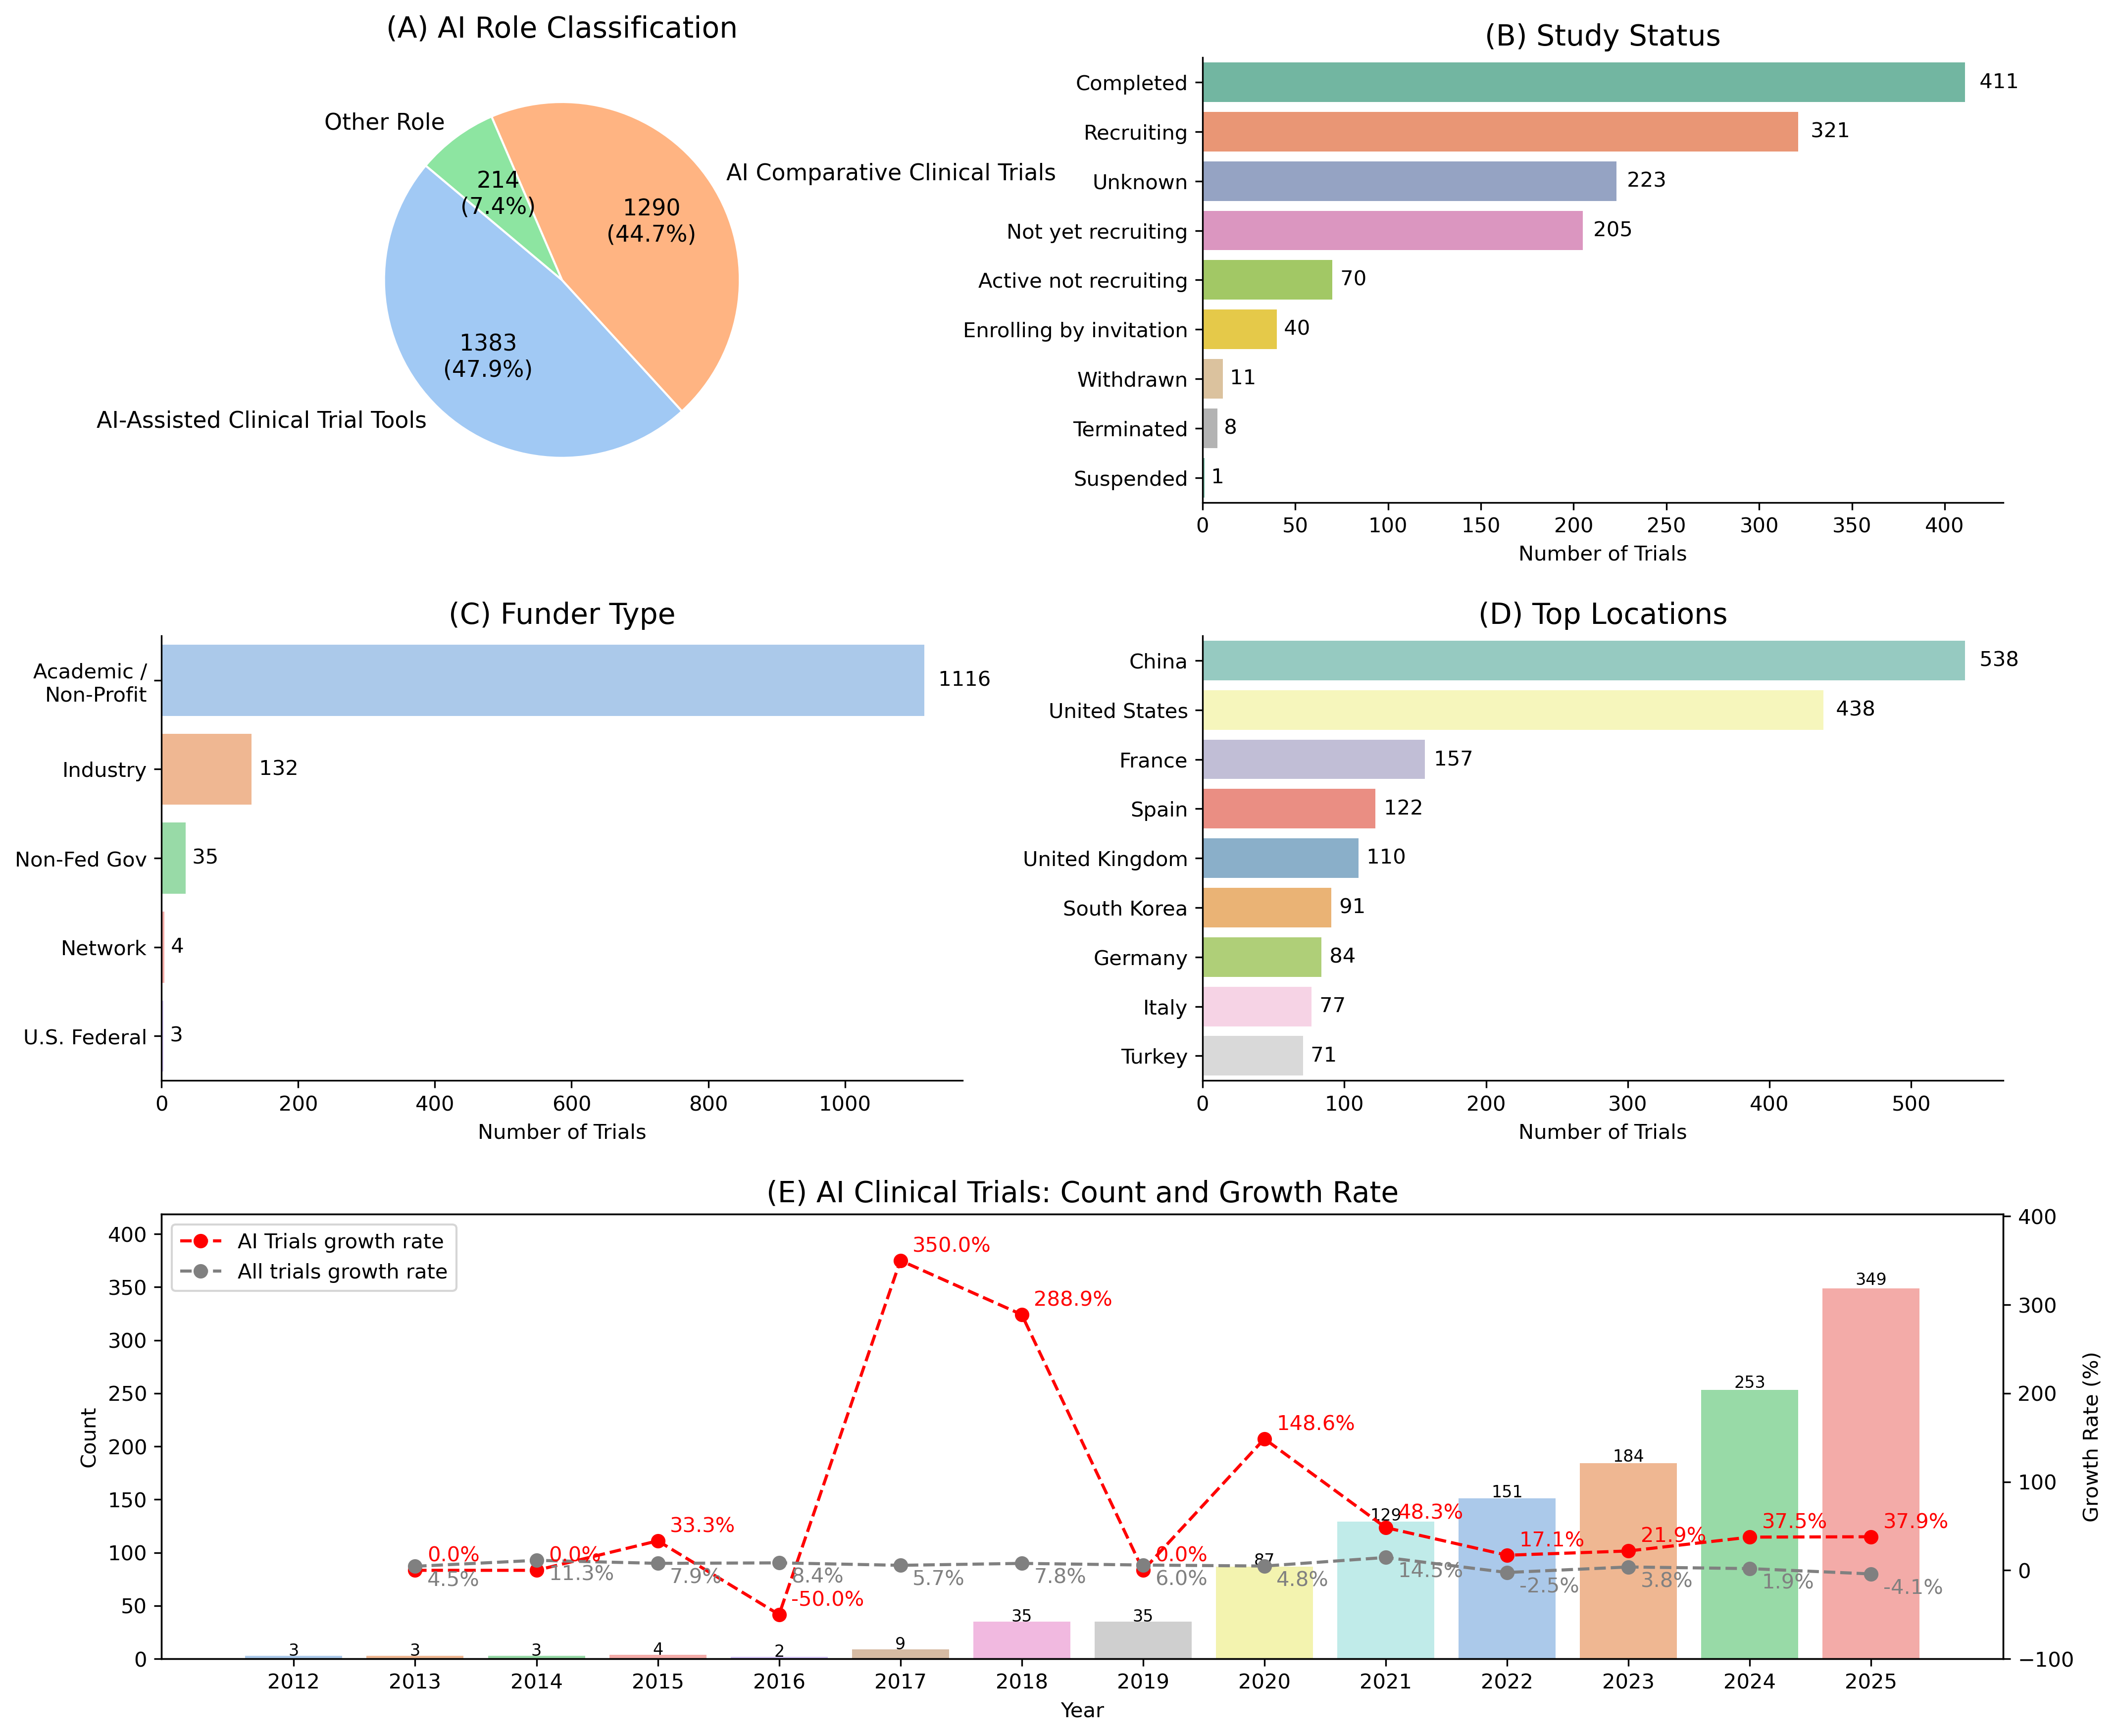

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# --- 2. SETUP FIGURE WITH REDUCED SPACER ---

fig = plt.figure(figsize=(16, 14), dpi=300)
gs = fig.add_gridspec(3, 2, 
                      height_ratios=[1, 1, 1],
                      hspace=0.3, wspace=0.3)

text_args = {'fontsize': 10, 'va': 'center'}

# --- ROW 1 ---
ax1 = fig.add_subplot(gs[0, 0])

pie_counts = df_results["AI Role"].value_counts()

total_pie = pie_counts.sum()

def fmt(x): return '{:.0f}\n({:.1f}%)'.format(x * total_pie / 100, x)
colors_pie = sns.color_palette('pastel')[0:len(pie_counts)]
ax1.pie(pie_counts, labels=pie_counts.index, autopct=fmt, startangle=140, colors=colors_pie, textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white'})
ax1.set_title('(A) AI Role Classification', fontsize=14, pad=10)

ax2 = fig.add_subplot(gs[0, 1])

status_counts = trials["Study Status"].value_counts()
revised_status_label = [i.replace("_", " ").capitalize() for i in status_counts.index]

sns.barplot(x=status_counts.values, y=revised_status_label, palette="Set2", ax=ax2)
ax2.set_title('(B) Study Status', fontsize=14)
ax2.set_xlabel("Number of Trials")
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
for i, v in enumerate(status_counts.values): ax2.text(v + (v * 0.01), i, f' {v}', **text_args)

# --- ROW 2 ---
ax3 = fig.add_subplot(gs[1, 0])

funder_counts = trials["Funder Type"].value_counts()
funder_mapping = {'OTHER': 'Academic /\nNon-Profit', 'INDUSTRY': 'Industry', 
    'OTHER_GOV': 'Non-Fed Gov',
    'NETWORK': 'Network', 'FED': 'U.S. Federal',}
revised_funder_label = [funder_mapping.get(i) for i in funder_counts.index]

sns.barplot(x=funder_counts.values, y=revised_funder_label, palette="pastel", ax=ax3)
ax3.set_title('(C) Funder Type', fontsize=14)
ax3.set_xlabel("Number of Trials")
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
for i, v in enumerate(funder_counts.values): ax3.text(v + (v * 0.01), i, f' {v}', **text_args)

ax4 = fig.add_subplot(gs[1, 1])
top_k = 9
loc_counts = all_loc["location"].value_counts()[:top_k]
revised_loc_label = ["Turkey" if x == "Turkey (Türkiye)" else x for x in loc_counts.index]

sns.barplot(x=loc_counts.values, y=revised_loc_label, palette="Set3", ax=ax4)
ax4.set_title(f'(D) Top Locations', fontsize=14)
ax4.set_xlabel("Number of Trials")
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
for i, v in enumerate(loc_counts.values): ax4.text(v + (v * 0.01), i, f' {v}', **text_args)



# --- ROW 3  ---
ax7 = fig.add_subplot(gs[2, :]) 


plot_year_increasing_on_axis(
    ax_bar=ax7,
    count_col="Number of AI Trials", 
    increase_col="AI rate of increase (%)",
    second_increase_col="rate of increase (%)", 
    title="(E) AI Clinical Trials: Count and Growth Rate", 
    off_set_1_positive=5,
    off_set_1_negative=5,
    lower_y=2, 
    upper_y=1.15
)

plt.tight_layout()
plt.savefig("Figure/Figure_2.png", dpi=300, bbox_inches='tight')
plt.show()